In [1]:
anno_path = "/home/maelic/Documents/Datasets/as_v2/rec_detailed_description_42k_wo_square_pad.json"

import json

with open(anno_path, 'r') as f:
    anno = json.load(f)

print(len(anno))

42551


In [2]:
print(anno[0].keys())

dict_keys(['id', 'image', 'height', 'width', 'conversations'])


In [3]:
from collections import defaultdict
import re
from PIL import Image, ImageDraw

BOX_SCALE = 999
REF_START_TAG = '<ref>'
REF_END_TAG = '</ref>'
BOX_START_TAG = '<box>'
BOX_END_TAG = '</box>'
REL_START_TAG = '<pred>'
REL_END_TAG = '</pred>'
SQUARE_PAD = True
DEBUG_MODE = False

def extract_objects(
    grounded_caption: str,
    grounded_pattern: str = r'<.*?>.*?<.*?>',
):
    objects = defaultdict(list)
    relations = defaultdict(list)

    clean_caption = grounded_caption
    clean_caption = clean_caption.replace(REF_START_TAG, '').replace(REF_END_TAG, '')
    clean_caption = clean_caption.replace(REL_START_TAG, '').replace(REL_END_TAG, '')
    res = re.findall(grounded_pattern, grounded_caption)

    last_tag = REF_START_TAG
    last_tag_value = 'Unknown'
    for item in res:
        clean_item = re.sub(r'<.*?>', '', item)

        if item.startswith(BOX_START_TAG):
            clean_caption = clean_caption.replace(item, '')
            try:
                clean_item = json.loads(clean_item)
            except Exception as e:
                # print('Invalid format:', clean_item)
                continue
            if last_tag == REF_START_TAG:
                objects[last_tag_value].extend(clean_item)
            elif last_tag == REL_START_TAG:
                relations[last_tag_value].append(clean_item)
            else:
                raise NotImplementedError(grounded_caption)
        else:
            last_tag = REF_START_TAG if item.startswith(REF_START_TAG) else REL_START_TAG
            last_tag_value = clean_item

    bbox2category = defaultdict(list)
    for k, v in objects.items():
        for bbox in v:
            bbox2category[json.dumps(bbox)].append(k)

    # print(objects)
    # print()
    # print(relations)
    # print()
    # print(grounded_caption)
    # print()
    # print(clean_caption)
    # print()
    return objects, relations, bbox2category

def parse_caption_and_update_image(image: Image, caption: str):
    image = image.copy()
    image_list = []
    caption_list = []
    # sections = []
    objects, relations, bbox2category = extract_objects(caption.replace('<image>', '').replace('</s>', ''))
    for obj_name, bbox_list in objects.items():
        if len(bbox_list) == 0:
            continue
        for idx, bbox in enumerate(bbox_list):
            try:
                x1, y1, x2, y2 = bbox
            except Exception as e:
                continue
            bbox = (
                int(x1 / BOX_SCALE * image.width),
                int(y1 / BOX_SCALE * image.height),
                int(x2 / BOX_SCALE * image.width),
                int(y2 / BOX_SCALE * image.height),
            )
            # sections.append((bbox, f'{obj_name}-{idx}'))
            image_list.append(image.copy())
            caption_list.append(f'{obj_name}-{idx}')

            # ImageDraw.Draw(image_list[-1]).rectangle(bbox, width=5, outline='red')

    scene_graph = []
    for rel_name, bbox_list in relations.items():
        # if len(bbox_list) % 2 != 0:
        #     print(f'Invalid bbox num [{len(bbox_list)}] for relation [{rel_name}]')
        #     print(f'Current caption: {caption}')
        #     print()

        for i in range(0, len(bbox_list), 2):
            if i+1 >= len(bbox_list):
                continue

            subject_bboxes = bbox_list[i]
            object_bboxes = bbox_list[i+1]

            if len(subject_bboxes) == 1:
                subject_bboxes = subject_bboxes * len(object_bboxes)

            if len(object_bboxes) == 1:
                object_bboxes = object_bboxes * len(subject_bboxes)

            if len(subject_bboxes) != len(object_bboxes):
                print(f'#subject_bboxes ({len(subject_bboxes)}) is not equal to #object_bboxes ({len(object_bboxes)})')
                print(f'Current caption: {caption}')
                print()

            for idx, (subj_bbox, obj_bbox) in enumerate(zip(subject_bboxes, object_bboxes)):
                subj = bbox2category[json.dumps(subj_bbox)]
                obj = bbox2category[json.dumps(obj_bbox)]

                try:
                    x1, y1, x2, y2 = subj_bbox
                except Exception as e:
                    continue

                subj_bbox = (
                    int(x1 / BOX_SCALE * image.width),
                    int(y1 / BOX_SCALE * image.height),
                    int(x2 / BOX_SCALE * image.width),
                    int(y2 / BOX_SCALE * image.height),
                )

                try:
                    x1, y1, x2, y2 = obj_bbox
                except Exception as e:
                    continue
                obj_bbox = (
                    int(x1 / BOX_SCALE * image.width),
                    int(y1 / BOX_SCALE * image.height),
                    int(x2 / BOX_SCALE * image.width),
                    int(y2 / BOX_SCALE * image.height),
                )
                # sections.append((subj_bbox, f'{subj}-{rel_name}-{i}-{idx}-subj'))
                # sections.append((obj_bbox, f'{obj}-{rel_name}-{i}-{idx}-obj'))
                image_list.append(image.copy())
                caption_list.append(f'{subj}-{rel_name}-{obj}')
                scene_graph.append((subj, subj_bbox, obj, obj_bbox, rel_name))

                # ImageDraw.Draw(image_list[-1]).rectangle(subj_bbox, width=5, outline='red')
                # ImageDraw.Draw(image_list[-1]).rectangle(obj_bbox, width=5, outline='blue')

    # for t in scene_graph:
    #     print(t)

    return scene_graph

In [4]:
coco_path = "/home/maelic/Documents/Datasets/coco/"
import random
random.shuffle(anno)
img_path = coco_path + anno[0]['image']
# load image
image = Image.open(img_path)
scene_graph = parse_caption_and_update_image(image, anno[0]['conversations'][1]['value'])
print(scene_graph)
print(anno[0])

[(['elderly woman'], (176, 57, 473, 433), ['chair'], (387, 185, 514, 439), 'sitting on'), (['elderly woman'], (176, 57, 473, 433), ['cake'], (35, 329, 192, 439), 'looking at'), (['dining table'], (35, 300, 475, 470), ['elderly woman'], (176, 57, 473, 433), 'in front of'), (['oranges'], (129, 365, 174, 389), ['oranges'], (144, 359, 183, 376), 'beside'), (['oranges'], (129, 365, 174, 389), ['cake'], (35, 329, 192, 439), 'on'), (['oranges'], (144, 359, 183, 376), ['cake'], (35, 329, 192, 439), 'on'), (['vase'], (519, 95, 579, 206), ['table'], (510, 176, 609, 240), 'on'), (['mirror'], (458, 18, 602, 96), ['wall'], (160, 36, 613, 399), 'hanging from'), (['door'], (35, 36, 184, 345), ['wall'], (160, 36, 613, 399), 'in')]
{'id': -1, 'image': 'coco/train2017/000000172506.jpg', 'height': 514, 'width': 640, 'conversations': [{'from': 'human', 'value': '<image>\nProvide a scene graph caption of the given image.'}, {'from': 'gpt', 'value': 'In the image, an <ref>elderly woman</ref><box>[[276, 111,

In [5]:
for idx, img_anno in enumerate(anno):
    img_path = coco_path + anno[0]['image']


[(['people', 'person'], (324, 233, 365, 302), ['elephants', 'elephant'], (315, 265, 368, 392), 'on the back of'), (['people', 'person'], (9, 147, 170, 344), ['elephants', 'elephant'], (0, 268, 173, 477), 'on the back of'), (['people', 'person'], (324, 233, 365, 302), ['elephants', 'elephant'], (315, 265, 368, 392), 'riding'), (['people', 'person'], (9, 147, 170, 344), ['elephants', 'elephant'], (0, 268, 173, 477), 'riding'), (['elephants', 'elephant'], (315, 265, 368, 392), ['people', 'person'], (324, 233, 365, 302), 'carrying'), (['people', 'person'], (9, 147, 170, 344), ['elephants', 'elephant'], (0, 268, 173, 477), 'on'), (['people', 'person'], (9, 147, 170, 344), ['sports ball'], (263, 120, 296, 154), 'looking at'), (['people', 'people'], (581, 295, 600, 357), ['people', 'people'], (603, 296, 622, 357), 'beside'), (['people', 'people'], (603, 296, 622, 357), ['people', 'people'], (581, 295, 600, 357), 'beside'), (['people'], (557, 298, 585, 377), ['people', 'people'], (581, 295, 60

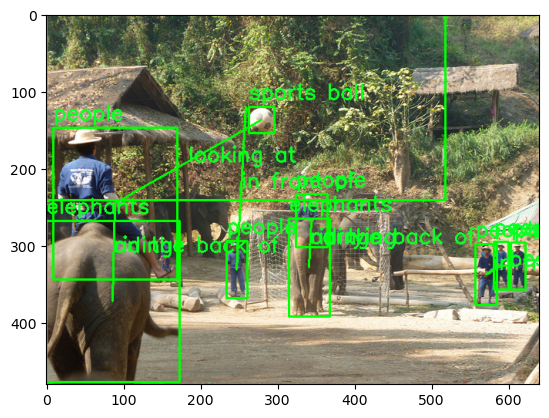

In [6]:
print(scene_graph)
import cv2 
img = cv2.imread(img_path)

for triplet in scene_graph:
    subj, subj_bbox, obj, obj_bbox, rel = triplet

    # draw bounding boxes and labels
    cv2.rectangle(img, (subj_bbox[0], subj_bbox[1]), (subj_bbox[2], subj_bbox[3]), (0, 255, 0), 2)
    cv2.rectangle(img, (obj_bbox[0], obj_bbox[1]), (obj_bbox[2], obj_bbox[3]), (0, 255, 0), 2)
    cv2.putText(img, subj[0], (subj_bbox[0], subj_bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)
    cv2.putText(img, obj[0], (obj_bbox[0], obj_bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)

    # draw line between objects centers
    center_sub = (int((subj_bbox[0] + subj_bbox[2]) / 2), int((subj_bbox[1] + subj_bbox[3]) / 2))
    center_obj = (int((obj_bbox[0] + obj_bbox[2]) / 2), int((obj_bbox[1] + obj_bbox[3]) / 2))

    cv2.line(img, center_sub, center_obj, (0, 255, 0), 2)
    # put text in the middle of the line
    cv2.putText(img, rel, (int((center_sub[0] + center_obj[0]) / 2), int((center_sub[1] + center_obj[1]) / 2)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)

img_cv2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

import matplotlib.pyplot as plt
plt.imshow(img_cv2)

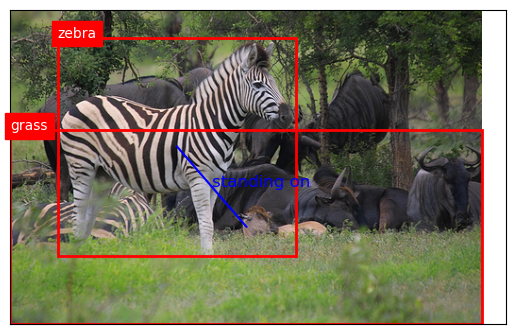

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
coco_path = "/home/maelic/Documents/Datasets/coco/"
import random
random.shuffle(anno)
img_path = coco_path + anno[0]['image']
# load image
image = Image.open(img_path)
scene_graph = parse_caption_and_update_image(image, anno[0]['conversations'][1]['value'])

fig, ax = plt.subplots()
ax.imshow(image)

for rel in scene_graph:
    subject, subject_bbox, obj, obj_bbox, rel = rel
    subject = subject[0]
    obj = obj[0]

    # draw bbox
    ax.add_patch(patches.Rectangle((subject_bbox[0], subject_bbox[1]), subject_bbox[2]-subject_bbox[0], subject_bbox[3]-subject_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))
    ax.add_patch(patches.Rectangle((obj_bbox[0], obj_bbox[1]), obj_bbox[2]-obj_bbox[0], obj_bbox[3]-obj_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))

    # get center of bbox
    subject_center = ((subject_bbox[0] + subject_bbox[2]) / 2, (subject_bbox[1] + subject_bbox[3]) / 2)
    obj_center = ((obj_bbox[0] + obj_bbox[2]) / 2, (obj_bbox[1] + obj_bbox[3]) / 2)

    # draw line
    ax.plot([subject_center[0], obj_center[0]], [subject_center[1], obj_center[1]], 'blue')

    # draw bboxes labels on top left with background rectangle
    ax.text(subject_bbox[0], subject_bbox[1], subject, fontsize=10, color='white', backgroundcolor='red')
    ax.text(obj_bbox[0], obj_bbox[1], obj, fontsize=10, color='white', backgroundcolor='red')

    # draw relation label on center of line
    ax.text((subject_center[0] + obj_center[0]) / 2, (subject_center[1] + obj_center[1]) / 2, rel, fontsize=12, color='blue')

# remove ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [8]:
# here we get the predicate distribution
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

rel_count = Counter()
obj_count = Counter()

for img in tqdm(anno):
    img_path = coco_path + img['image']
    # load image
    image = Image.open(img_path)
    scene_graph = parse_caption_and_update_image(image, img['conversations'][1]['value'])
    for rel in scene_graph:
        subject, subject_bbox, obj, obj_bbox, rel = rel

        if len (subject) == 0 or len(obj) == 0:
            continue
        subject = subject[0]
        obj = obj[0]

        rel_count[rel] += 1
        obj_count[subject] += 1
        obj_count[obj] += 1

# plot predicate distribution
rel_count = dict(rel_count)
rel_count = {k: v for k, v in sorted(rel_count.items(), key=lambda item: item[1], reverse=True)}

plt.figure(figsize=(20, 10))
sns.barplot(x=list(rel_count.keys()), y=list(rel_count.values()))
plt.xticks(rotation=90)
plt.show()

  1%|▏         | 546/42551 [00:08<09:45, 71.76it/s]

#subject_bboxes (2) is not equal to #object_bboxes (3)
Current caption: In the image, three <ref>people</ref><box>[[0, 529, 171, 760], [123, 17, 503, 970], [524, 70, 827, 984]]</box> are engaged in playing a video game inside a room. Two of the individuals are <pred>standing</pred><box>[[123, 17, 503, 970], [524, 70, 827, 984]]</box><box>[[0, 704, 236, 998], [426, 754, 999, 998]]</box> on different types of flooring: one on a <ref>wooden floor</ref><box>[[426, 754, 999, 998]]</box> and the other on a different section of <ref>floor</ref><box>[[0, 704, 236, 998]]</box>. Both are <pred>holding</pred><box>[[123, 17, 503, 970], [524, 70, 827, 984]]</box><box>[[357, 302, 403, 362], [451, 313, 485, 366], [669, 169, 695, 188]]</box> <ref>remotes</ref><box>[[357, 302, 403, 362], [451, 313, 485, 366], [669, 169, 695, 188]]</box>, which are likely video game controllers. The third person is <pred>sitting on</pred><box>[[0, 529, 171, 760]]</box><box>[[1, 394, 181, 810]]</box> a <ref>couch</ref><b

  1%|▏         | 574/42551 [00:09<11:16, 62.08it/s]


KeyboardInterrupt: 

In [ ]:
# show only top 50
plt.figure(figsize=(20, 10))
sns.barplot(x=list(rel_count.keys())[:50], y=list(rel_count.values())[:50], palette="viridis")
plt.xticks(rotation=75)
plt.title('Top 50 Relative Counts')
plt.xlabel('Predicate', fontsize=12)
plt.ylabel('Count', fontsize=12)
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# compute mean and median of relation per image
rel_sum = sum(rel_count.values())
rel_mean = rel_sum / len(anno)

print(f'Mean relation per image: {rel_mean}')

print(len(rel_count))

In [ ]:
space_sgg_path  = "/home/maelic/Documents/Datasets/space_sgg/gpt4o-space-sgg-desc-10k.json"

with open(space_sgg_path, 'r') as f:
    space_sgg_anno = json.load(f)

print(len(space_sgg_anno))
print(space_sgg_anno[0].keys())


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
coco_path = "/home/maelic/Documents/Datasets/coco/"
import random
random.shuffle(space_sgg_anno)
img_path = coco_path + space_sgg_anno[0]['image']
# load image
image = Image.open(img_path)
scene_graph = parse_caption_and_update_image(image, space_sgg_anno[0]['conversations'][1]['value'])
print(space_sgg_anno[0]['conversations'][1]['value'])

fig, ax = plt.subplots()
ax.imshow(image)

for rel in scene_graph:
    subject, subject_bbox, obj, obj_bbox, rel = rel
    print(subject, subject_bbox, obj, obj_bbox, rel)
    subject = subject[0]
    obj = obj[0]

    # draw bbox

    ax.add_patch(patches.Rectangle((subject_bbox[0], subject_bbox[1]), subject_bbox[2]-subject_bbox[0], subject_bbox[3]-subject_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))
    ax.add_patch(patches.Rectangle((obj_bbox[0], obj_bbox[1]), obj_bbox[2]-obj_bbox[0], obj_bbox[3]-obj_bbox[1], linewidth=2, edgecolor='r', facecolor='none'))

    # get center of bbox
    subject_center = ((subject_bbox[0] + subject_bbox[2]) / 2, (subject_bbox[1] + subject_bbox[3]) / 2)
    obj_center = ((obj_bbox[0] + obj_bbox[2]) / 2, (obj_bbox[1] + obj_bbox[3]) / 2)

    # draw line
    ax.plot([subject_center[0], obj_center[0]], [subject_center[1], obj_center[1]], 'blue')

    # draw bboxes labels on top left with background rectangle
    ax.text(subject_bbox[0], subject_bbox[1], subject, fontsize=10, color='white', backgroundcolor='red')
    ax.text(obj_bbox[0], obj_bbox[1], obj, fontsize=10, color='white', backgroundcolor='red')

    # draw relation label on center of line
    ax.text((subject_center[0] + obj_center[0]) / 2, (subject_center[1] + obj_center[1]) / 2, rel, fontsize=12, color='blue')

# remove ticks
ax.set_xticks([])
ax.set_yticks([])
plt.show()

100%|██████████| 10104/10104 [01:28<00:00, 113.98it/s]
/tmp/ipykernel_1772716/834713699.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(rel_count.keys())[:50], y=list(rel_count.values())[:50], palette="viridis")


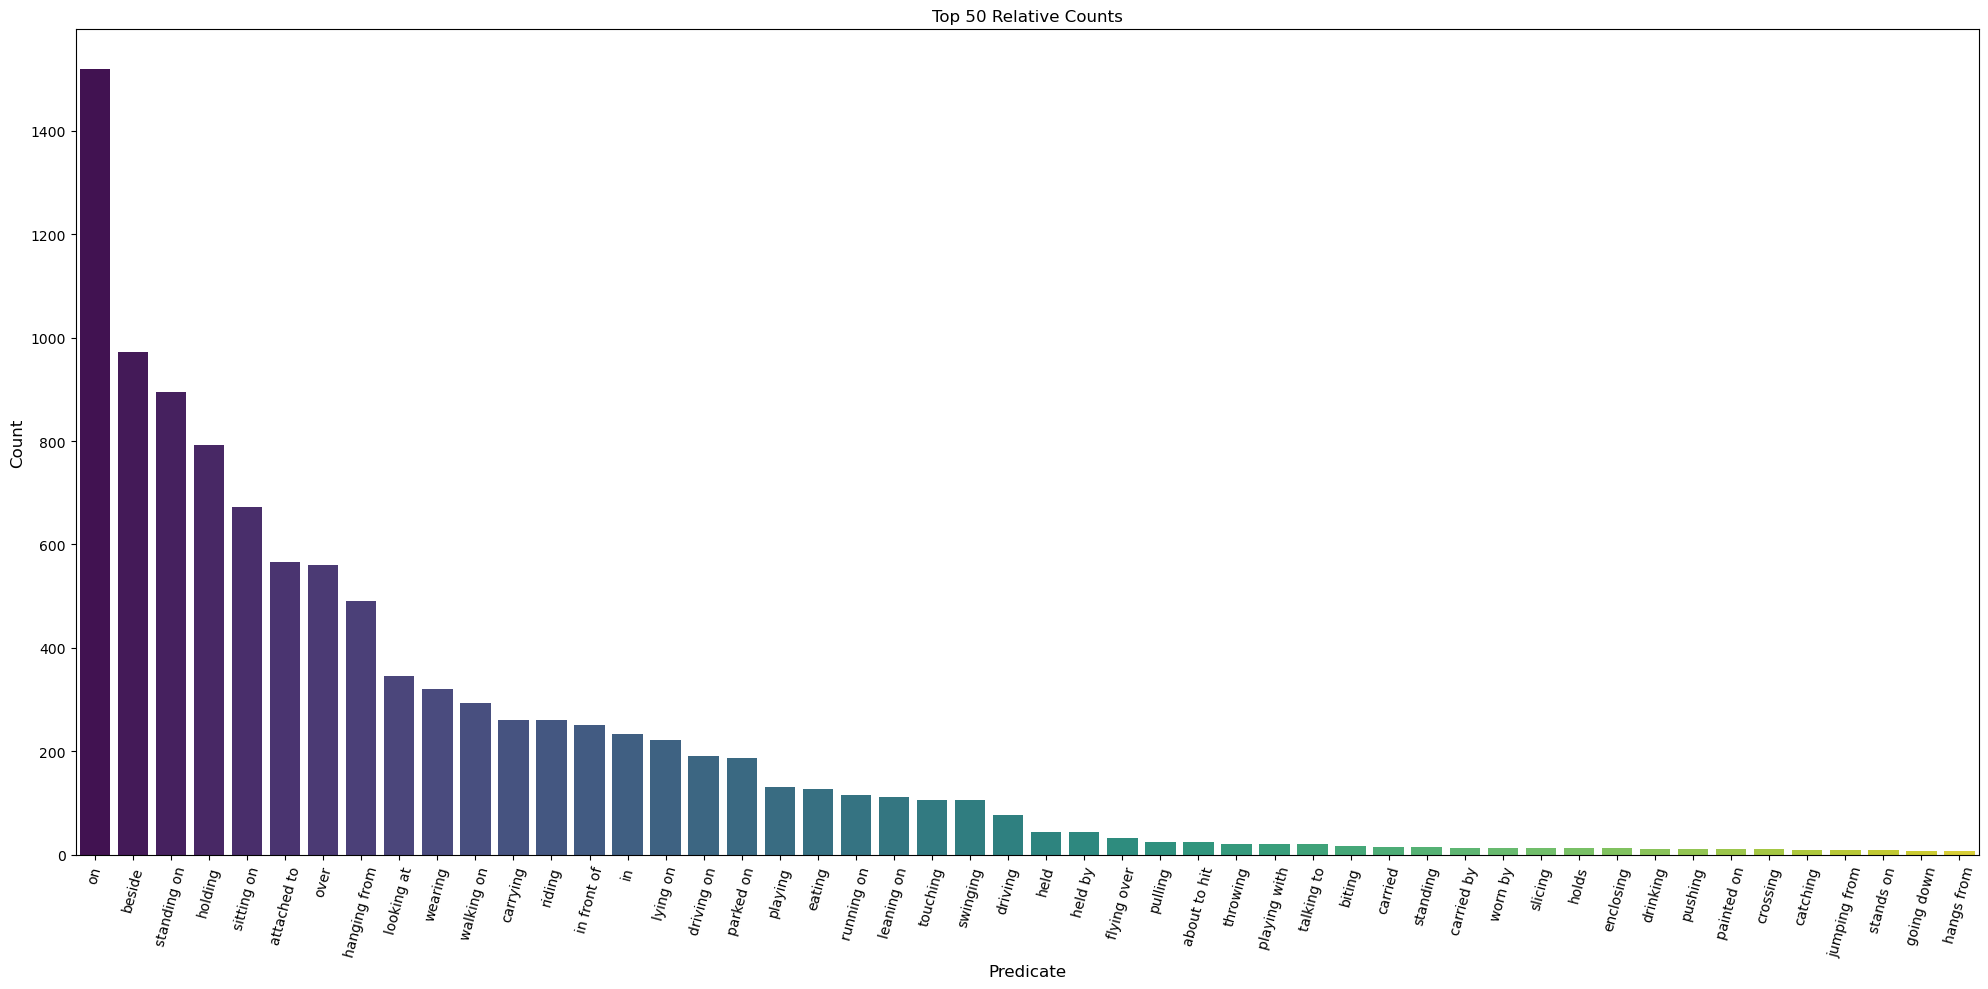

In [ ]:
# here we get the predicate distribution
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

rel_count = Counter()
obj_count = Counter()

for img in tqdm(space_sgg_anno):
    img_path = coco_path + img['image']
    # load image
    image = Image.open(img_path)
    scene_graph = parse_caption_and_update_image(image, img['conversations'][1]['value'])
    for rel in scene_graph:
        subject, subject_bbox, obj, obj_bbox, rel = rel

        if len (subject) == 0 or len(obj) == 0:
            continue
        subject = subject[0]
        obj = obj[0]

        rel_count[rel] += 1
        obj_count[subject] += 1
        obj_count[obj] += 1

# plot predicate distribution
rel_count = dict(rel_count)
rel_count = {k: v for k, v in sorted(rel_count.items(), key=lambda item: item[1], reverse=True)}

# show only top 50
plt.figure(figsize=(20, 10))
sns.barplot(x=list(rel_count.keys())[:50], y=list(rel_count.values())[:50], palette="viridis")
plt.xticks(rotation=75)
plt.title('Top 50 Relative Counts')
plt.xlabel('Predicate', fontsize=12)
plt.ylabel('Count', fontsize=12)
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()